# **Predicting Hospital Readmission in Diabetic Patients: A Machine Learning Study Using the Diabetes 130-US Hospitals Dataset**

Author: Ushna Khan


# Abstract

Hospital readmissions among diabetic patients pose a significant challenge to healthcare systems, contributing to increased medical costs and poorer patient outcomes. This study utilizes the Diabetes 130-US Hospitals (1999–2008) dataset from the UCI Machine Learning Repository to predict whether a patient will be readmitted after discharge. The dataset includes over 101,000 patient encounters and 47 clinical and demographic attributes covering patient characteristics, admission details, and treatment information.

For the purpose of this study, the target variable was reframed as a binary classification task: readmitted versus not readmitted. After data cleaning and removal of invalid entries, the final dataset contained 67,329 patient encounters, with the majority falling into the “not readmitted” category. A series of machine learning experiments were conducted to identify which demographic, hospital, and treatment-related features are most predictive of readmission risk.

The process involved data cleaning, feature transformation, and evaluation of Logistic Regression and Random Forest performance. Preliminary results suggest that hospital utilization factors—such as medication counts, number of laboratory procedures, and time spent in the hospital—are strong predictors of readmission, while demographic variables contribute only limited predictive power. The study demonstrates how interpretable models can be used to uncover clinical insights into diabetic patient management and readmission risk.

# Introduction
Hospital readmission is a key indicator of healthcare quality and efficiency. For patients with diabetes, readmission rates are particularly high and costly, reflecting complications in treatment and medication adherence. Accurately predicting which diabetic patients are likely to be readmitted after discharge can assist hospitals in allocating resources, improving follow-up care, and reducing preventable readmissions.

The Diabetes 130-US Hospitals for Years 1999–2008 dataset provides a large-scale, real-world record of more than 100,000 hospital encounters across 130 U.S. hospitals. It captures both demographic and clinical aspects of patient care, including diagnoses, medication use, admission type, and length of stay. In the original dataset, encounters are categorized as “no readmission”, “readmitted <30 days”, or “readmitted >30 days.” In this study, the task is reframed as a binary classification problem by grouping all readmission cases into a single readmitted class and contrasting them with the not readmitted class. After clean-up, the final dataset consists of 67,329 encounters.

The principal goal of this investigation is to understand which patient, hospital, and treatment attributes most influence overall readmission risk. Specifically, the project addresses the following research questions:
	1.	Does class balancing (given that non-readmissions outnumber readmissions) improve precision and recall for the minority class?
	2.	Which feature categories—demographic, medication-related, or hospital utilization attributes—contribute most to predictive power?
	3.	Do demographic variables such as sex, age, or race show any evidence of bias in prediction or feature weighting?

By approaching the problem through both statistical and machine learning methods, this project aims not only to achieve strong predictive performance but also to reveal the underlying factors that drive readmission behavior among diabetic patients.

# Motivation

The dataset was originally analyzed by Strack et al., who examined statistical associations between patient characteristics, treatments, and readmission outcomes. Their work highlighted several influential factors such as diagnosis categories and HbA1c testing practices. They also introduced the disease-grouping structure commonly used in later studies. Since then, researchers have applied a wide range of machine learning approaches to the same dataset, from traditional models (Logistic Regression, SVMs, Random Forests) to more recent architectures such as gradient boosting and neural networks. Many studies report improvements through techniques like class balancing, feature selection, or embedding-based representations.

However, much of the existing literature focuses heavily on performance metrics, often using complex models that sacrifice interpretability. Relatively fewer studies investigate how different feature groups contribute to prediction, how class imbalance affects precision and recall, or whether demographic variables behave in ways that could indicate bias.

This project builds on previous research but shifts the focus toward interpretability and clinical relevance. Rather than aiming for state-of-the-art accuracy, the goal is to understand how different categories of features like demographic, clinical, treatment-related, and diagnosis-based, shape the prediction of readmission versus non-readmission. This provides a more transparent and practically useful understanding of readmission risk in diabetic patients.

# Section 1: Data Loading and Preprocessing

In [ ]:
# import pdb
# from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

## Data Loading

In [ ]:
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# LOADING DATA
# data_file = '/content/drive/My Drive/Colab Notebooks/CSC 321/Diabates Data/diabetic_data.csv'

data_file = Path("../data/diabetic_data.csv")

data = pd.read_csv(data_file)
pre_rows, pre_cols = data.shape

print("This is the Diabetes data set. It has", pre_rows, "instances, and it has", pre_cols, "features.")

This is the Diabetes data set. It has 101766 instances, and it has 50 features.


In [ ]:
no, early, late = data['readmitted'].value_counts()
print("The initial of target values are:\n")
print("NO REDADMISSION:",no)
print("<30 (EARLY):",early)
print(">30 (LATE):",late)

The initial of target values are:

NO REDADMISSION: 54864
<30 (EARLY): 35545
>30 (LATE): 11357


In [ ]:
# Convert to binary target
data['readmitted'] = data['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)

print("\nBinary target value counts:\n")
print(data['readmitted'].value_counts())


Binary target value counts:

readmitted
0    54864
1    46902
Name: count, dtype: int64


In [ ]:
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,0


#### Handling Missing Values
According to Strack et al. (2014) which is the introductory paper for this dataset on UCI's repository, Table 1 reports that the features weight, payer_code, and medical_specialty contain the largest proportions of missing data, approximately 97%, 52%, and 53%, respectively. These three features are removed entirely from the dataset prior to further analysis.

Moreover, most patients have 'None' for max_glu_serum and A1Cresult because those tests were not routinely performed during hospitalization. Due to the low variance in the feature values, they will also be dropped.


In [ ]:
# REMOVING FEATURES
print(f"Dropping columns with high missingness and low variance.")
data = data.drop(columns=['max_glu_serum', 'A1Cresult', 'weight', 'payer_code', 'medical_specialty'],errors='ignore')
post_cols = data.shape[1]
print(f"We now have {post_cols} features")

Dropping columns with high missingness and low variance.
We now have 45 features


Some remaining attributes may still carry little or no information for predicting readmission. For example, columns where nearly all patients have the same category (e.g., drugs never prescribed).
- Numeric columns: using the standard deviation
- Categorical columns: examining the frequency of the most common value

ADD  extremely rare diabetes drugs

In [ ]:
low_var_features = []

num_cols = data.select_dtypes(include=[np.number]).columns
cat_cols = data.select_dtypes(exclude=[np.number]).columns

for col in num_cols:
    if data[col].std() == 0:
        low_var_features.append(col)

for col in cat_cols:
    top_freq = data[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq > 0.90:
        low_var_features.append(col)

print(f"Identified {len(low_var_features)} low-variance features:")
print(low_var_features)

Identified 19 low-variance features:
['repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


In [ ]:
data = data.drop(columns=low_var_features, errors='ignore')
post_cols = data.shape[1]

print(f"\nFinal feature count: {post_cols}")


Final feature count: 26


Remaining missing entries were handled by simply removing the small number of incomplete rows to ensure data integrity without significantly affecting sample size.

In [ ]:
# HANDLING REMAINING MISSING VALUES
pre_rows = data.shape[0]
data = data.replace('?', np.nan)
data = data.dropna()
post_rows = data.shape[0]

print(f"Dropped {pre_rows - post_rows} rows "
      f"({(pre_rows - post_rows) / pre_rows * 100:.2f}%) containing missing values.")
print(f"Final dataset shape: {data.shape}")

Dropped 3713 rows (3.65%) containing missing values.
Final dataset shape: (98053, 26)


#### Removing Repeated Patient Records
The dataset contains multiple encounters for some patients (indicated by patient_nbr). Including multiple admissions from the same individual could bias the model, since encounters from the same patient are not truly independent and may share similar demographics, diagnoses, or treatment patterns.
Thus, we keep the first recorded encounter for each patient_nbr and remove subsequent duplicates.

In [ ]:
pre_rows = data.shape[0]
data = data.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
post_rows = data.shape[0]
print(f"Removed {pre_rows - post_rows} duplicate patient encounters.")
print(f"Final dataset now contains {post_rows} unique patients (one encounter each).")

# Drop patient and encounter identifiers (no predictive value)
data = data.drop(columns=['encounter_id', 'patient_nbr'])
print(f"Identifiers removed. Dataset shape: {data.shape}")

Removed 29423 duplicate patient encounters.
Final dataset now contains 68630 unique patients (one encounter each).
Identifiers removed. Dataset shape: (68630, 24)


## Feature Transformation

#### ID Mapping

The original ID fields (admission_source_id, discharge_disposition_id, admission_type_id) contain many categorical codes (20+ unique values each). To align with Strack et al. (2014) and simplify modeling:
- Admission Source was collapsed into three categories: Emergency Room, Physician/Clinic Referral, and Other.
- Discharge Disposition was collapsed into Discharged to Home and Other.
Encounters resulting in death or hospice discharge were removed to prevent bias in readmission analysis.
- Admission Type was dropped, since its information largely overlaps with Admission Source.

In [ ]:
# Admissions source type
def simplify_admission_source(x):
    if x == 7:
        return 'Emergency'
    elif x in [1, 2]:
        return 'Referral'
    else:
        return 'Other'

data['admission'] = data['admission_source_id'].apply(simplify_admission_source)

In [ ]:
# Discharge disposition type
def simplify_discharge(x):
    if x == 1:
        return 'Home'
    elif x in [11, 13, 19]:
        return 'Remove'
    else:
        return 'Other'

data['discharge'] = data['discharge_disposition_id'].apply(simplify_discharge)

# Remove hospice and death outcomes
pre_rows = data.shape[0]
data = data[data['discharge'] != 'Remove']
post_rows = data.shape[0]

print(f"Removed {pre_rows - post_rows} terminal/hospice encounters "
      f"({(pre_rows - post_rows) / pre_rows * 100:.2f}% of data).")

data = data.drop(columns=['admission_type_id','discharge_disposition_id','admission_source_id'])

Removed 1301 terminal/hospice encounters (1.90% of data).


In [ ]:
data[['admission','discharge']].head()

,admission,discharge
8,Other,Home
9,Other,Other
4,Emergency,Home
10,Emergency,Home
5,Referral,Home


In [ ]:
# One hot encoding
data = pd.get_dummies(data, columns=['admission', 'discharge'], prefix=['adm', 'disch'],drop_first=True)
data[['adm_Other',	'adm_Referral',	'disch_Other']].head()

,adm_Other,adm_Referral,disch_Other
8,True,False,False
9,True,False,True
4,False,False,False
10,False,False,False
5,False,True,False


In [ ]:
print(f"Dataset shape: {data.shape}")

Dataset shape: (67329, 24)


#### Consolidating diagnosis codes

The variables diag_1, diag_2, and diag_3, represent primary and secondary diagnosis codes (often ICD-9 or ICD-10). Each of these have hundreds of unique codes, making direct modeling infeasible. To handle this, we can group diagnosis codes into broader diagnostic categories, (Circulatory system diseases, Respiratory system diseases, Diabetes-related conditions, Infectious diseases, Injury, Genitourinary, Neoplasms (cancers), Muscoskeletal, and Other conditions) in accordance to Table 2 of of the research report Strack et al. (2014).

In [ ]:
data[['diag_1','diag_2','diag_3']].head()

,diag_1,diag_2,diag_3
8,398,427,38
9,434,198,486
4,197,157,250
10,250.7,403,996
5,414,411,250


In [ ]:
# Creating categories
def map_icd9_category(code):
    try:
        code_num = float(code)
    # handle E or V codes/ other non-integer codes
    except ValueError:
        return 'Other'

    if 250 <= code_num < 251:
        return 'Diabetes'
    elif (390 <= code_num <= 459) or (code_num == 785):
        return 'Circulatory'
    elif (460 <= code_num <= 519) or (code_num == 786):
        return 'Respiratory'
    elif (520 <= code_num <= 579) or (code_num == 787):
        return 'Digestive'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif (580 <= code_num <= 629) or (code_num == 788):
        return 'Genitourinary'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

# create categorical columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    data[col + '_cat'] = data[col].apply(map_icd9_category)

# drop code columns
data = data.drop(['diag_1', 'diag_2', 'diag_3'], axis=1)

In [ ]:
data[['diag_1_cat', 'diag_2_cat', 'diag_3_cat']].head()

,diag_1_cat,diag_2_cat,diag_3_cat
8,Circulatory,Circulatory,Other
9,Circulatory,Neoplasms,Respiratory
4,Neoplasms,Neoplasms,Diabetes
10,Diabetes,Circulatory,Injury
5,Circulatory,Circulatory,Diabetes


In [ ]:
# define diagnosis groups
categories = [
    'Circulatory', 'Respiratory', 'Digestive', 'Injury',
    'Musculoskeletal', 'Genitourinary', 'Neoplasms',
    'Diabetes', 'Other'
]

# create a new column for each category
for cat in categories:
    data[f'{cat}'] = (
        (data['diag_1_cat'] == cat) |
        (data['diag_2_cat'] == cat) |
        (data['diag_3_cat'] == cat)
    ).astype(int)

# drop categorical columns
data = data.drop(columns=['diag_1_cat', 'diag_2_cat', 'diag_3_cat'])

In [ ]:
data[categories].head()

,Circulatory,Respiratory,Digestive,Injury,Musculoskeletal,Genitourinary,Neoplasms,Diabetes,Other
8,1,0,0,0,0,0,0,0,1
9,1,1,0,0,0,0,1,0,0
4,0,0,0,0,0,0,1,1,0
10,1,0,0,1,0,0,0,1,0
5,1,0,0,0,0,0,0,1,0


In [ ]:
print(f"Dataset shape: {data.shape}")

Dataset shape: (67329, 30)


#### Transforming Binary Categories
Specifically, we transform:
- gender: represents biological sex (male/1 or female/0).
- diabetesMed: indicates whether any diabetic medication was prescribed (yes/1 or no/0).
- change: indicates whether there was a change in diabetic medication during the encounter (change/0 or no change/1).


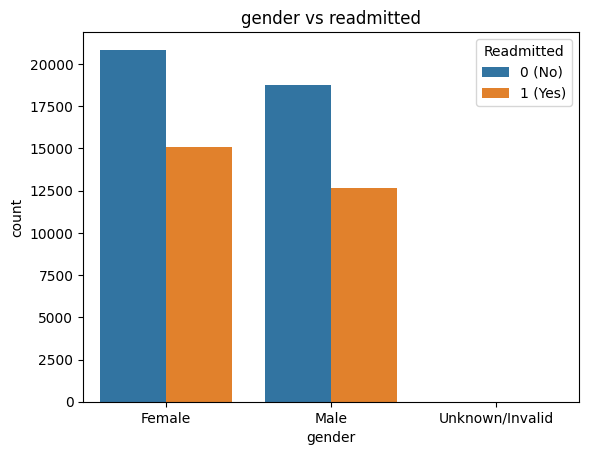

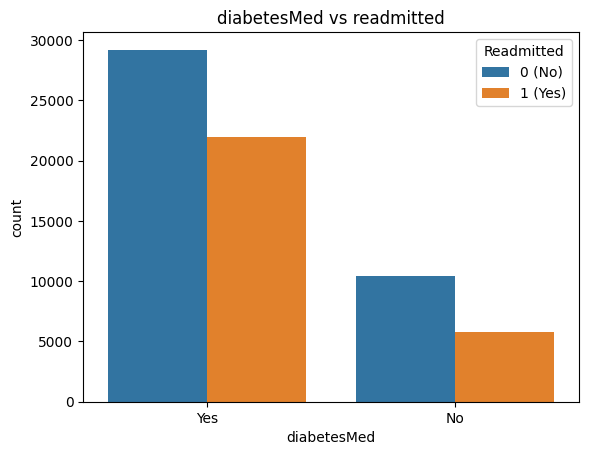

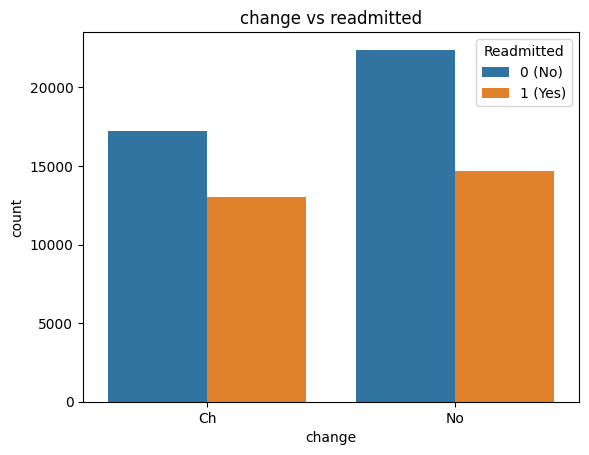

In [ ]:
for feature in ['gender', 'diabetesMed', 'change']:
  sns.countplot(x=feature,hue='readmitted',data=data)
  plt.title(f'{feature} vs readmitted')
  plt.legend(title='Readmitted',labels=['0 (No)', '1 (Yes)'])
  plt.show()

In [ ]:
le_gender = preprocessing.LabelEncoder()
le_diabetesMed = preprocessing.LabelEncoder()
le_change = preprocessing.LabelEncoder()

# Encode gender
le_gender.fit(data['gender'])
data['gender'] = le_gender.transform(data['gender'])

# Encode diabetesMed
le_diabetesMed.fit(data['diabetesMed'])
data['diabetesMed'] = le_diabetesMed.transform(data['diabetesMed'])

# Encode change
le_change.fit(data['change'])
data['change'] = le_change.transform(data['change'])

data[['gender', 'diabetesMed', 'change']].head()

,gender,diabetesMed,change
8,0,1,0
9,0,1,0
4,1,1,0
10,0,1,1
5,1,1,1


Remove instances where gender is unknown and is encoded as 2.

In [ ]:
# drop the rows where gender == 2
invalid_rows = data[data['gender'] == 2].shape[0]
print("Rows with invalid gender:", invalid_rows)

data = data[data['gender'] != 2]

Rows with invalid gender: 1


#### Encoding Prescription Drug Features
The four prescription variables (metformin, glipizide, glyburide, insulin) each describe whether the drug was prescribed and if its dosage changed during the hospital encounter (Values: up, down, steady, and no). To reduce sparsity while retaining key information, each drug was label-encoded according to the following:

- 0, if 'No' (not prescribed)
- 1, if 'Steady' (no dosage change)
- 2, if 'Up' (dosage increased)
- -1, if 'Down' (dosage decreased)

In [ ]:
def encode_drug(value):
    if value == "No":
        return 0
    elif value == "Steady":
        return 1
    elif value == "Up":
        return 2
    elif value == "Down":
        return -1

drug_cols = ["metformin", "glipizide", "glyburide", "insulin"]

for col in drug_cols:
    data[col] = data[col].apply(encode_drug)

data[drug_cols].head()

,metformin,glipizide,glyburide,insulin
8,0,1,0,1
9,0,0,0,1
4,0,1,0,1
10,0,0,0,1
5,0,0,0,1


In [ ]:
# drug_features = ['metformin', 'glipizide', 'glyburide', 'insulin']

# for drug in drug_features:
#     data[f'{drug}_prescribed'] = np.where(data[drug] != 'no', 1, 0)
#     data[f'{drug}_change'] = np.where(data[drug].isin(['up', 'down']), 1, 0)

# data = data.drop(columns=drug_features)

# print(f"Dataset shape after encoding drug features: {data.shape}\n")
# data.head()

#### Encoding Race

The race variable originally contains five categories: Caucasian, AfricanAmerican, Hispanic, Asian, and Other. Due to the small number of instances for the Asian and Hispanic categories, they were combined into Other, resulting in three final race groups: Caucasian, AfricanAmerican, and Other.

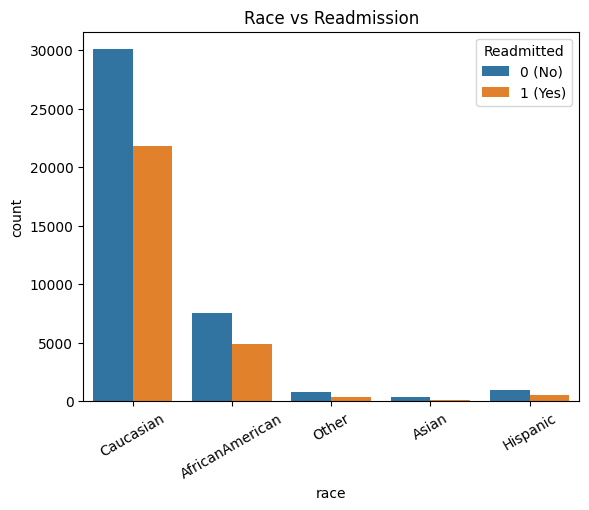

In [ ]:
sns.countplot(x='race',hue='readmitted',data=data)
plt.title('Race vs Readmission')
plt.legend(title='Readmitted',labels=['0 (No)', '1 (Yes)'])
plt.xticks(rotation=30)
plt.show()

In [ ]:
data['race'].value_counts()

,count
race,
Caucasian,51830
AfricanAmerican,12423
Hispanic,1462
Other,1136
Asian,477


In [ ]:
data['race'] = data['race'].replace({'Hispanic': 'Other', 'Asian': 'Other'})

data = pd.get_dummies(data, columns=['race'], prefix='race', drop_first=True)

print(f"Dataset shape after encoding race: {data.shape}\n")
data[['race_Caucasian','race_Other']].head()

Dataset shape after encoding race: (67328, 31)



,race_Caucasian,race_Other
8,True,False
9,True,False
4,True,False
10,False,False
5,True,False


#### Encoding Age

The age variable represents 10-year intervals, such as [0-10), [10-20), up to [90-100). To simplify this feature and make it more clinically meaningful, these intervals were grouped into three broader categories:
- ≤30 years old
- 30–60 years old
- \>60 years old

In [ ]:
def simplify_age(age_str):
    # extract lower bound from age group
    lower = int(age_str.strip('[]').split('-')[0])
    if lower < 30:
        return '<30'
    elif 30 <= lower < 60:
        return '30-60'
    else:
        return '>60'

data['age_group'] = data['age'].apply(simplify_age)

# one-hot encode age groups
data = pd.get_dummies(data, columns=['age_group'], prefix='age', drop_first=True)
data = data.drop(columns='age')

print(f"Dataset shape after encoding age: {data.shape}\n")
data[['age_<30','age_>60']].head()

Dataset shape after encoding age: (67328, 32)



,age_<30,age_>60
8,False,True
9,False,True
4,False,False
10,False,False
5,False,False


In [ ]:
data.head()

,gender,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,...,Injury,Musculoskeletal,Genitourinary,Neoplasms,Diabetes,Other,race_Caucasian,race_Other,age_<30,age_>60
8,0,13,68,2,28,0,0,0,8,0,...,0,0,0,0,0,1,True,False,False,True
9,0,12,33,3,18,0,0,0,8,0,...,0,0,0,1,0,0,True,False,False,True
4,1,1,51,0,8,0,0,0,5,0,...,0,0,0,1,1,0,True,False,False,False
10,0,9,47,2,17,0,0,0,9,0,...,1,0,0,0,1,0,False,False,False,False
5,1,3,31,6,16,0,0,0,9,0,...,0,0,0,0,1,0,True,False,False,False


## Exploratory Data Analysis (EDA):

#### Basic Summary

In [ ]:
#dataset overview
print(f"This is our Final Diabates Dataset.\nIt has {data.shape[0]} instances and {data.shape[1]} features.")

# summary statistics

# numeric features only
num_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]
print("\nSummary statistics:")
display(data[num_features].describe().T)

This is our Final Diabates Dataset.
It has 67328 instances and 32 features.

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
time_in_hospital,67328.0,4.305133,2.944568,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,67328.0,42.945491,19.954000,1.0,31.0,44.0,57.0,132.0
num_procedures,67328.0,1.437827,1.759652,0.0,0.0,1.0,2.0,6.0
num_medications,67328.0,15.768402,8.264492,1.0,10.0,14.0,20.0,81.0
number_outpatient,67328.0,0.287176,1.080785,0.0,0.0,0.0,0.0,42.0
number_emergency,67328.0,0.106880,0.519424,0.0,0.0,0.0,0.0,42.0
number_inpatient,67328.0,0.183653,0.611966,0.0,0.0,0.0,0.0,12.0
number_diagnoses,67328.0,7.328808,1.891815,3.0,6.0,8.0,9.0,16.0


In [ ]:
# Normalization
scaled = StandardScaler().fit_transform(data[num_features])
scaledData = pd.DataFrame(scaled, columns=num_features)

In [ ]:
scaledData.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
0,2.952872,1.255623,0.319482,1.480029,-0.265713,-0.205768,-0.300106,0.354790
1,2.613261,-0.498425,0.887780,0.270024,-0.265713,-0.205768,-0.300106,0.354790
2,-1.122459,0.403657,-0.817114,-0.939980,-0.265713,-0.205768,-0.300106,-1.231001
3,1.594428,0.203194,0.319482,0.149024,-0.265713,-0.205768,-0.300106,0.883387
4,-0.443237,-0.598656,2.592675,0.028023,-0.265713,-0.205768,-0.300106,0.883387


In [ ]:
display(scaledData.describe().T)

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,67328.0,1.143994e-16,1.000007,-1.122459,-0.782848,-0.103627,0.575595,3.292483
num_lab_procedures,67328.0,-1.519697e-16,1.000007,-2.102125,-0.598656,0.052847,0.704351,4.463024
num_procedures,67328.0,7.851767e-17,1.000007,-0.817114,-0.817114,-0.248816,0.319482,2.592675
num_medications,67328.0,-7.387416e-17,1.000007,-1.786984,-0.697979,-0.213978,0.512025,7.893054
number_outpatient,67328.0,1.815194e-17,1.000007,-0.265713,-0.265713,-0.265713,-0.265713,38.595210
number_emergency,67328.0,2.585595e-18,1.000007,-0.205768,-0.205768,-0.205768,-0.205768,80.653671
number_inpatient,67328.0,2.617256e-17,1.000007,-0.300106,-0.300106,-0.300106,-0.300106,19.308970
number_diagnoses,67328.0,2.735454e-16,1.000007,-2.288195,-0.702404,0.354790,0.883387,4.583565


#### Visualizing Features

<Figure size 640x480 with 0 Axes>

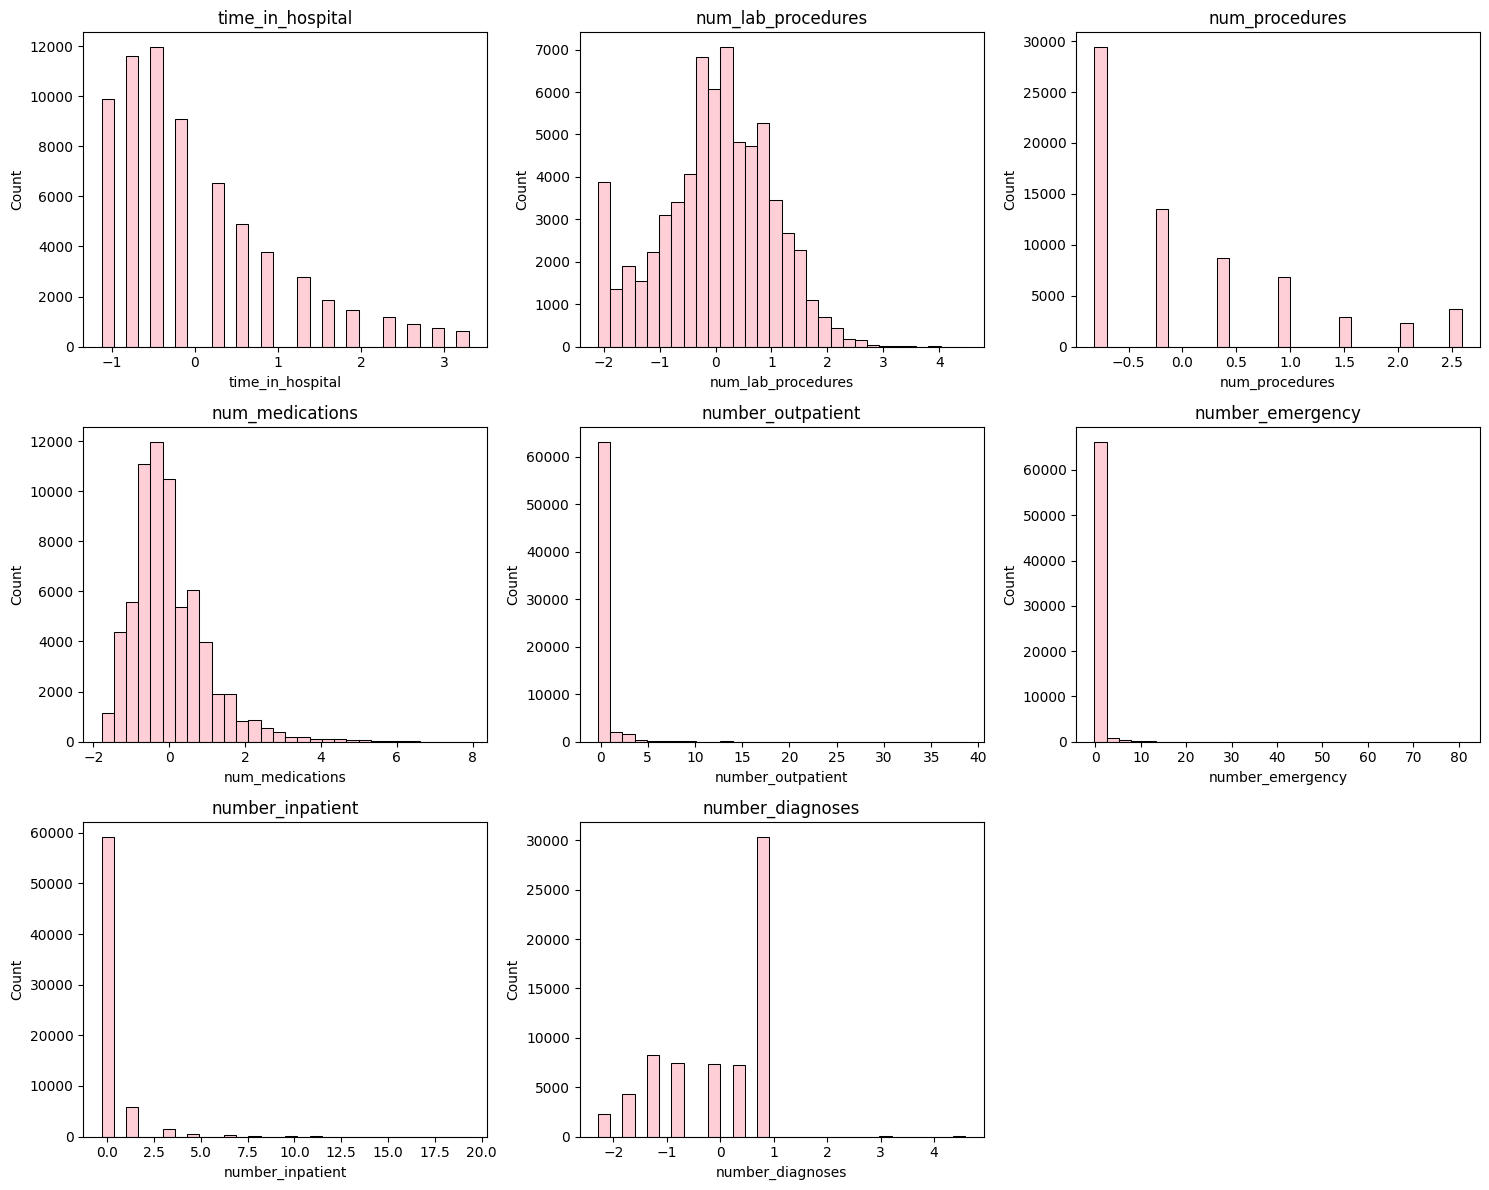

In [ ]:
# Plot
plt.tight_layout()
plt.figure(figsize=(15, 12))

for i, col in enumerate(num_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(scaledData[col], bins=30, kde=False, color='pink')
    plt.title(col)

plt.tight_layout()
plt.show()

The variables number_outpatient, number_emergency, and number_inpatient represent the number of times a patient was seen in these settings during the observation period. Their distributions are extremely right-skewed, with the vast majority of patients having a value of 0


#### Target Distribution

In [ ]:
#target distribution
print("Target proportions:\n")
print(data['readmitted'].value_counts(normalize=True),'\n')

Target proportions:

readmitted
0    0.588151
1    0.411849
Name: proportion, dtype: float64 



#### Correlation Matrix

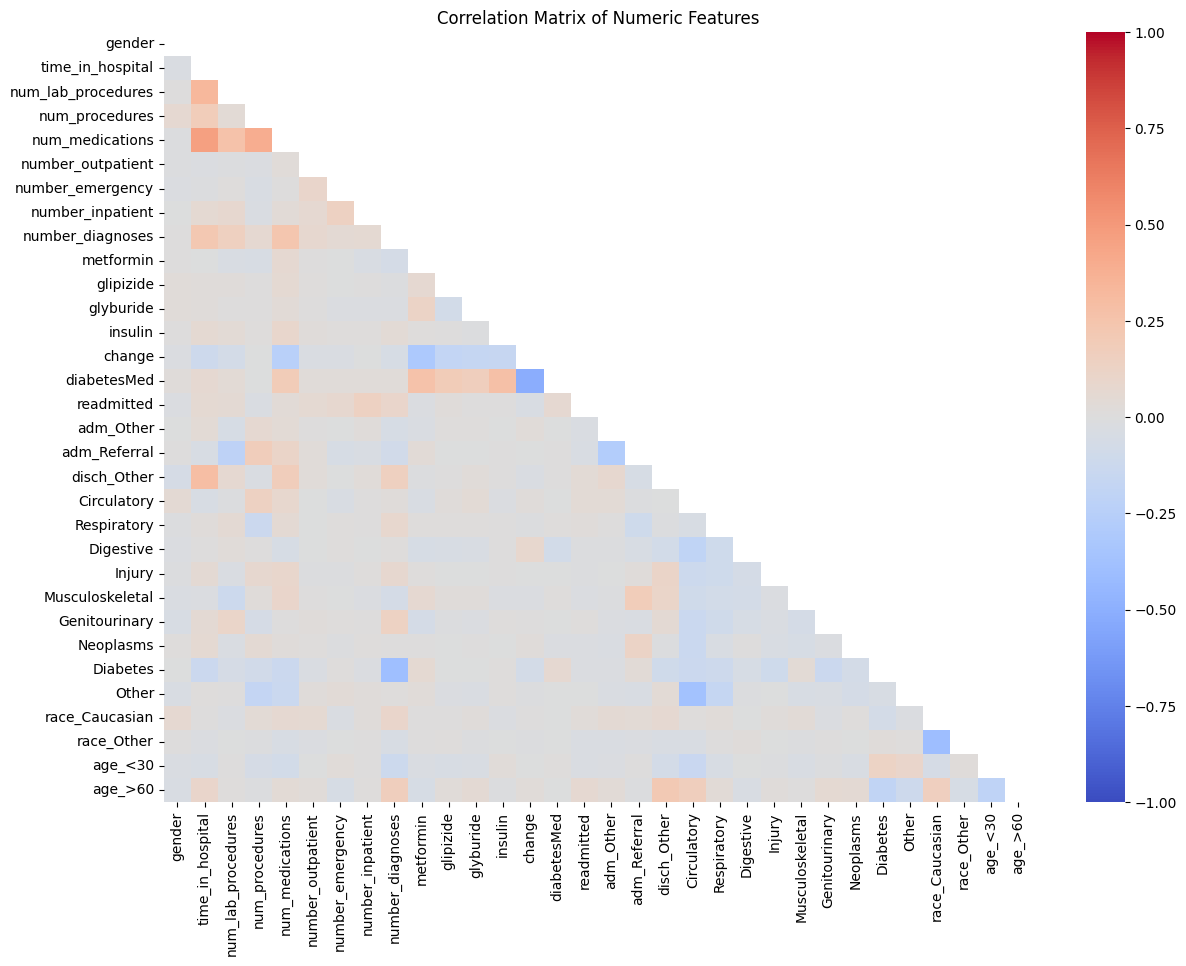

In [ ]:
# Correlation matrix for numeric features only
numeric_cols = data.select_dtypes(include=['int64', 'float64', 'bool']).columns
mask = np.triu(np.ones_like(data[numeric_cols].corr(), dtype=bool))
plt.figure(figsize=(14,10))
sns.heatmap(data[numeric_cols].corr(), cmap='coolwarm',mask=mask, center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

Overall, the majority of correlations are very weak, with most values falling between -0.2 and +0.2. There is a small cluster of modest relationsips in ime in hospital, number of lab procedures, number of medications, number of inpatient visits, and number of diagnoses. This makes sense intuitively since patients who undergo more hospital services in one category tend to require more services in others. In contrast, demographic variables (gender, race, age group) exhibit almost no correlation with either clinical variables or the readmission outcome.

# Section 2: Model Evalutation and Experiments

## Baseline Model
We establish baseline predictive performance without any balancing or feature manipulation. We evaluate two fundamentally different types of models:
- Logistic Regression: a classifier that assumes a linear relationship between features and readmission risk.
-	Random Forest Classifier: a non-linear, ensemble tree-based model capable of capturing complex interactions between clinical, demographic, and medication features.

To ensure a reliable and unbiased performance estimate, we use stratified 10-fold cross-validation, which preserves the proportion of readmitted vs. not-readmitted cases within each fold. A ZeroR baseline (DummyClassifier) is also included to verify that the predictive models outperform majority-class guessing.

In [ ]:
data.head()

,gender,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,...,Injury,Musculoskeletal,Genitourinary,Neoplasms,Diabetes,Other,race_Caucasian,race_Other,age_<30,age_>60
8,0,13,68,2,28,0,0,0,8,0,...,0,0,0,0,0,1,True,False,False,True
9,0,12,33,3,18,0,0,0,8,0,...,0,0,0,1,0,0,True,False,False,True
4,1,1,51,0,8,0,0,0,5,0,...,0,0,0,1,1,0,True,False,False,False
10,0,9,47,2,17,0,0,0,9,0,...,1,0,0,0,1,0,False,False,False,False
5,1,3,31,6,16,0,0,0,9,0,...,0,0,0,0,1,0,True,False,False,False


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

X = data.drop('readmitted', axis=1).values
y = data['readmitted'].values

# STORE METRICS
results = {"LR": {"acc": [], "prec": [], "rec": [], "f1": [], "auc": []},"RF": {"acc": [], "prec": [], "rec": [], "f1": [], "auc": []},"ZeroR": {"acc": []}}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # SCALE
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ZERO R
    zr = DummyClassifier(strategy="most_frequent")
    zr.fit(X_train_scaled, y_train)
    y_pred_zr = zr.predict(X_test_scaled)
    results["ZeroR"]["acc"].append(accuracy_score(y_test, y_pred_zr))

    # LOGISTIC REGRESSION
    lr = LogisticRegression(solver='liblinear')
    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)
    y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

    results["LR"]["acc"].append(accuracy_score(y_test, y_pred_lr))
    results["LR"]["prec"].append(precision_score(y_test, y_pred_lr))
    results["LR"]["rec"].append(recall_score(y_test, y_pred_lr))
    results["LR"]["f1"].append(f1_score(y_test, y_pred_lr))
    results["LR"]["auc"].append(roc_auc_score(y_test, y_prob_lr))

    # RANDOM FOREST
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_train_scaled, y_train)
    y_pred_rf = rf.predict(X_test_scaled)
    y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

    results["RF"]["acc"].append(accuracy_score(y_test, y_pred_rf))
    results["RF"]["prec"].append(precision_score(y_test, y_pred_rf))
    results["RF"]["rec"].append(recall_score(y_test, y_pred_rf))
    results["RF"]["f1"].append(f1_score(y_test, y_pred_rf))
    results["RF"]["auc"].append(roc_auc_score(y_test, y_prob_rf))

# PRINT RESULTS

def summarize(model_name):
    metrics = results[model_name]
    print(f"\n=== {model_name} 10-Fold CV Results ===")
    for m, vals in metrics.items():
        print(f"{m.upper():<6}: Mean={np.mean(vals):.4f}, Std={np.std(vals):.4f}")

summarize("ZeroR")
summarize("LR")
summarize("RF")


=== ZeroR 10-Fold CV Results ===
ACC   : Mean=0.5882, Std=0.0000

=== LR 10-Fold CV Results ===
ACC   : Mean=0.6149, Std=0.0035
PREC  : Mean=0.5867, Std=0.0121
REC   : Mean=0.2198, Std=0.0090
F1    : Mean=0.3196, Std=0.0099
AUC   : Mean=0.6249, Std=0.0056

=== RF 10-Fold CV Results ===
ACC   : Mean=0.6144, Std=0.0041
PREC  : Mean=0.5527, Std=0.0084
REC   : Mean=0.3351, Std=0.0066
F1    : Mean=0.4172, Std=0.0065
AUC   : Mean=0.6242, Std=0.0069


The ZeroR baseline achieves 58.8% accuracy, which reflects the majority-class proportion. This tells us the dataset is imbalanced, and simply predicting the majority class performs reasonably well.

Both Logistic Regression and Random Forest perform only slightly better than ZeroR in accuracy (61%). This small improvement suggests that the models are having difficulty learning meaningful patterns.

Precision for both models is moderate (0.55–0.59), meaning when the model predicts “readmitted,” it is correct about half the time.
However, recall is very low, especially for Logistic Regression (0.22) and only slightly better for Random Forest (0.33). This means the models miss most of the actual readmitted patients.

F1-scores are low (0.32 for LR, 0.42 for RF) because of poor recall.
AUC scores are around 0.62 for both, indicating only weak discrimination between the two classes.

## Class Balancing


In [ ]:
from imblearn.over_sampling import SMOTE

# results dictionary
results_smote = {"LR": {"acc": [], "prec": [], "rec": [], "f1": [], "auc": []},"RF": {"acc": [], "prec": [], "rec": [], "f1": [], "auc": []},"ZeroR": {"acc": []}}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
sm = SMOTE(random_state=42)

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # scale BEFORE SMOTE
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

    # ZERO R BASELINE
    zr = DummyClassifier(strategy="most_frequent")
    zr.fit(X_train_bal, y_train_bal)
    y_pred_zr = zr.predict(X_test_scaled)
    results_smote["ZeroR"]["acc"].append(accuracy_score(y_test, y_pred_zr))

    # LOGISTIC REGRESSION
    lr = LogisticRegression(solver='liblinear')
    lr.fit(X_train_bal, y_train_bal)
    y_pred_lr = lr.predict(X_test_scaled)
    y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

    results_smote["LR"]["acc"].append(accuracy_score(y_test, y_pred_lr))
    results_smote["LR"]["prec"].append(precision_score(y_test, y_pred_lr))
    results_smote["LR"]["rec"].append(recall_score(y_test, y_pred_lr))
    results_smote["LR"]["f1"].append(f1_score(y_test, y_pred_lr))
    results_smote["LR"]["auc"].append(roc_auc_score(y_test, y_prob_lr))

    # RANDOM FOREST
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_train_bal, y_train_bal)
    y_pred_rf = rf.predict(X_test_scaled)
    y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

    results_smote["RF"]["acc"].append(accuracy_score(y_test, y_pred_rf))
    results_smote["RF"]["prec"].append(precision_score(y_test, y_pred_rf))
    results_smote["RF"]["rec"].append(recall_score(y_test, y_pred_rf))
    results_smote["RF"]["f1"].append(f1_score(y_test, y_pred_rf))
    results_smote["RF"]["auc"].append(roc_auc_score(y_test, y_prob_rf))

# PRINT SUMMARY
def summarize_sm(model):
    print(f"\n=== {model} (SMOTE 10-Fold CV) ===")
    for metric, vals in results_smote[model].items():
        print(f"{metric.upper():<5} Mean={np.mean(vals):.4f}, Std={np.std(vals):.4f}")

summarize_sm("ZeroR")
summarize_sm("LR")
summarize_sm("RF")


=== ZeroR (SMOTE 10-Fold CV) ===
ACC   Mean=0.5882, Std=0.0000

=== LR (SMOTE 10-Fold CV) ===
ACC   Mean=0.5924, Std=0.0046
PREC  Mean=0.5047, Std=0.0052
REC   Mean=0.5482, Std=0.0089
F1    Mean=0.5255, Std=0.0064
AUC   Mean=0.6245, Std=0.0052

=== RF (SMOTE 10-Fold CV) ===
ACC   Mean=0.6100, Std=0.0050
PREC  Mean=0.5376, Std=0.0087
REC   Mean=0.3801, Std=0.0061
F1    Mean=0.4453, Std=0.0065
AUC   Mean=0.6222, Std=0.0070


Applying SMOTE to balance the target classes had a noticeable impact on model behavior, especially for Logistic Regression. As expected, the ZeroR baseline remained unchanged, since it always predicts the majority class and does not learn from the data.

For Logistic Regression, SMOTE significantly improved the model’s ability to identify positive (readmitted) cases. Recall increased from roughly 0.22 to 0.55, and the F1-score also rose from about 0.32 to 0.53. This indicates that after balancing, the model becomes much better at catching actual readmissions, although it does so at the cost of slightly lower precision. Accuracy dropped slightly, but this is expected with balanced data and is less meaningful than the large improvements in recall and F1.

For Random Forest, the effect of SMOTE was smaller. Recall improved moderately (from 0.33 to 0.38), and F1 increased slightly as well. This suggests that RF already handles class imbalance reasonably well on its own, so oversampling offers a smaller benefit compared to Logistic Regression. Precision and AUC remained relatively stable across both versions of the model.

## Feature Importance

In [ ]:
X = pd.DataFrame(X, columns=data.drop(columns=['readmitted']).columns)
y = data['readmitted']

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

num_lab_procedures    0.162905
num_medications       0.138287
time_in_hospital      0.092512
num_procedures        0.063317
number_diagnoses      0.059679
insulin               0.039261
gender                0.028663
Other                 0.026391
number_inpatient      0.025705
Diabetes              0.024261
Respiratory           0.023651
metformin             0.021811
race_Caucasian        0.021675
disch_Other           0.021203
number_outpatient     0.021040
adm_Referral          0.020149
Genitourinary         0.019887
glipizide             0.019586
glyburide             0.018304
Circulatory           0.018234
Digestive             0.018190
change                0.017447
age_>60               0.015585
Injury                0.014140
number_emergency      0.013435
adm_Other             0.012997
Musculoskeletal       0.011310
diabetesMed           0.009885
Neoplasms             0.009807
race_Other            0.007347
age_<30               0.003338
dtype: float64


The Random Forest results show that clinical severity and hospital‐utilization features are the strongest predictors of readmission, while demographics contribute very little.

Top Predictors (Most Important)
- num_lab_procedures, num_medications, time_in_hospital, num_procedures, number_diagnoses
These features all reflect how intensive or complex the hospital stay was. Patients who receive more tests, procedures, medications, or stay longer are more likely to be readmitted.

Moderate Predictors
- Medication features (insulin, metformin, glipizide, glyburide)
- Diagnosis groups (Diabetes, Respiratory, Circulatory, Digestive, etc.)
These provide useful but secondary information related to disease burden and treatment patterns.

Weak Predictors
- Age, gender, race, and other demographics
These have very low importance, suggesting the model does not rely heavily on demographic differences to make predictions. This might be due to imbalance in the data e.g. mostly caucasian patient encounters.

Conclusion: Readmission risk is driven mainly by clinical complexity, not by demographic attributes. This is a good indication that the model is focusing on meaningful medical factors and is unlikely to exhibit strong demographic bias.

## Grouping Features


In [ ]:
importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=X.columns)

# Define feature groups
groups = {
    "Demographic": ['gender', 'race_Caucasian', 'race_Other', 'age_<30', 'age_>60'],
    "Medication": ['metformin', 'glipizide', 'glyburide', 'insulin', 'diabetesMed', 'change'],
    "Hospital Info": ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                      'num_medications', 'number_outpatient', 'number_emergency',
                      'number_inpatient', 'number_diagnoses', 'adm_Other',
                      'adm_Referral', 'disch_Other'],
    "Diagnosis Categories": ['Circulatory','Respiratory','Digestive','Injury',
                             'Musculoskeletal','Genitourinary','Neoplasms',
                             'Diabetes','Other']
}

# Sum importance per group
group_scores = {g: feature_importance[cols].sum() for g, cols in groups.items()}

pd.Series(group_scores).sort_values(ascending=False)

,0
Hospital Info,0.631229
Diagnosis Categories,0.165869
Medication,0.126294
Demographic,0.076607


The grouped feature importance analysis shows that hospital-related variables (length of stay, number of lab tests, number of procedures, outpatient/emergency counts, etc.) contribute the majority of overall model importance. Diagnosis categories come next with moderate weight, while medication-related features contribute smaller but still meaningful predictive signals. Demographic features contribute the least overall. This suggests that clinical activity and hospital utilization are stronger indicators of readmission risk than demographic characteristics.

## Evaluating Model On Select Features

In [ ]:
strong_features = ['num_lab_procedures','num_medications','time_in_hospital','num_procedures','number_diagnoses']
weak_features = ['gender', 'race_Caucasian', 'race_Other', 'age_<30', 'age_>60']
moderate_features = ['insulin','metformin','glipizide','glyburide','Other','number_inpatient','number_outpatient',
                     'number_emergency','adm_Other','adm_Referral','disch_Other','Diabetes',
                     'Respiratory','Digestive','Circulatory','Genitourinary','Musculoskeletal',
                     'Neoplasms','Injury','change','diabetesMed']

In [ ]:
# Extract strong and moderate features
X_reduced = data.drop(columns=['readmitted']+ weak_features)
y = data['readmitted']

In [ ]:
# Extract strong features only
X_strong = data[strong_features].copy()
y = data['readmitted']

In [ ]:
def run_rf_cv(X, y, label=""):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

    accs = []
    precs = []
    recs = []
    f1s = []
    aucs = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Scale
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Model
        rf = RandomForestClassifier(n_estimators=200, random_state=0)
        rf.fit(X_train, y_train)
        preds = rf.predict(X_test)
        probs = rf.predict_proba(X_test)[:,1]

        accs.append(accuracy_score(y_test, preds))
        precs.append(precision_score(y_test, preds))
        recs.append(recall_score(y_test, preds))
        f1s.append(f1_score(y_test, preds))
        aucs.append(roc_auc_score(y_test, probs))

    print(f"\n=== Random Forest ({label}) ===")
    print(f"ACC   Mean={np.mean(accs):.4f}, Std={np.std(accs):.4f}")
    print(f"PREC  Mean={np.mean(precs):.4f}, Std={np.std(precs):.4f}")
    print(f"REC   Mean={np.mean(recs):.4f}, Std={np.std(recs):.4f}")
    print(f"F1    Mean={np.mean(f1s):.4f}, Std={np.std(f1s):.4f}")
    print(f"AUC   Mean={np.mean(aucs):.4f}, Std={np.std(aucs):.4f}")

# Run experiments
run_rf_cv(X_reduced, y, "Reduced (No Weak Predictors)")
run_rf_cv(X_strong, y, "Strong Predictors Only")


=== Random Forest (Reduced (No Weak Predictors)) ===
ACC   Mean=0.6077, Std=0.0041
PREC  Mean=0.5372, Std=0.0076
REC   Mean=0.3425, Std=0.0090
F1    Mean=0.4183, Std=0.0083
AUC   Mean=0.6142, Std=0.0061

=== Random Forest (Strong Predictors Only) ===
ACC   Mean=0.5468, Std=0.0060
PREC  Mean=0.4411, Std=0.0085
REC   Mean=0.3761, Std=0.0099
F1    Mean=0.4060, Std=0.0089
AUC   Mean=0.5333, Std=0.0076


The feature selection experiments explored whether model performance could be improved by removing weaker predictors or by training on only the strongest features.

Removing weak predictors (demographics such as age and race)
The Random Forest trained on the reduced feature set performed almost the same as the full model:
- Accuracy stayed around 0.61
- Precision and F1 were nearly unchanged
- AUC dropped slightly from 0.624 → 0.614
This suggests demographic variables do not strongly influence predictions and their removal does not improve or worsen performance in a meaningful way.

Using only the strongest predictors
When the model was trained using only the top five predictors (lab procedures, medications, time in hospital, procedures, number of diagnoses), performance dropped noticeably:
- Accuracy fell to 0.55
- AUC dropped to 0.53
- All other metrics declined

This means that the model relies on a broader combination of clinical and admission-related features, not just the top-ranked ones. While the strongest variables carry most of the predictive power, the additional moderate predictors still contribute important complementary information.

# Results

The experimental results compare several modelling strategies, including baseline prediction, standard classifiers, SMOTE-balanced models, and feature-selection variants. Logistic Regression and Random Forest both performed slightly better than the ZeroR baseline but achieved only modest accuracy overall. Applying SMOTE improved recall indicating that class imbalance was limiting the models's ability to detect readmitted patients. Feature selection experiments showed that removing weak predictors did not meaningfully improve performance, while restricting the model to only the strongest predictors caused a clear drop in accuracy and AUC. Overall, the results suggest that readmission is influenced by many small signals rather than a small set of dominant predictors.

In [ ]:
import pandas as pd

results = {
    "Model": ["ZeroR", "Logistic Regression", "Random Forest", "LR + SMOTE", "RF + SMOTE", "RF (Reduced)", "RF (Strong Only)"],
    "Accuracy": [0.5882, 0.6149, 0.6144, 0.5924, 0.6100, 0.6077, 0.5468],
    "Precision": [None, 0.5867, 0.5527, 0.5047, 0.5376, 0.5372, 0.4411],
    "Recall": [None, 0.2198, 0.3351, 0.5482, 0.3801, 0.3425, 0.3761],
    "F1": [None, 0.3196, 0.4172, 0.5255, 0.4453, 0.4183, 0.4060],
    "AUC": [None, 0.6249, 0.6242, 0.6245, 0.6222, 0.6142, 0.5333]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,ZeroR,0.5882,NaN,NaN,NaN,NaN
1,Logistic Regression,0.6149,0.5867,0.2198,0.3196,0.6249
2,Random Forest,0.6144,0.5527,0.3351,0.4172,0.6242
3,LR + SMOTE,0.5924,0.5047,0.5482,0.5255,0.6245
4,RF + SMOTE,0.6100,0.5376,0.3801,0.4453,0.6222
5,RF (Reduced),0.6077,0.5372,0.3425,0.4183,0.6142
6,RF (Strong Only),0.5468,0.4411,0.3761,0.4060,0.5333


/tmp/ipython-input-2047116775.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="F1", palette="viridis")


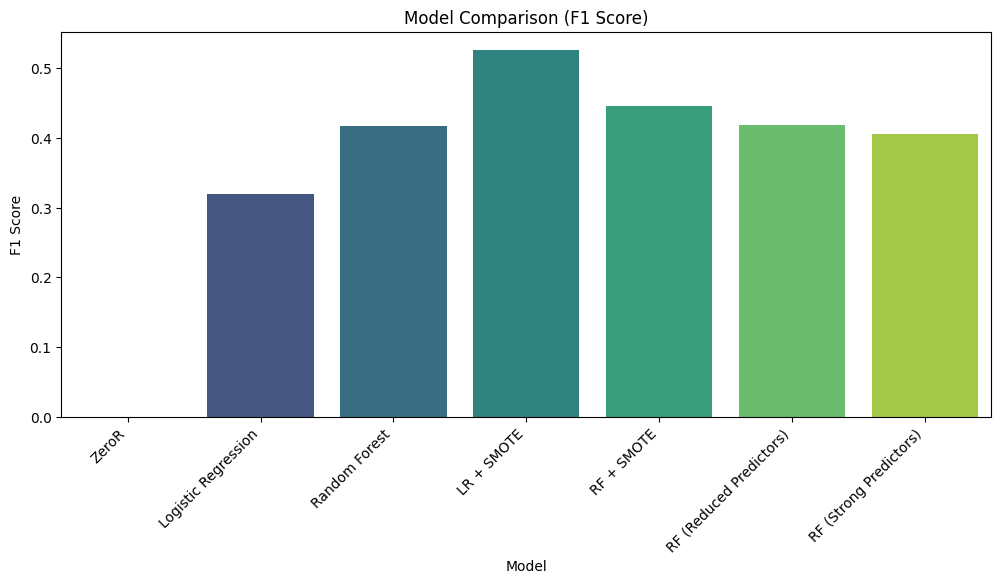

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(data=results_df, x="Model", y="F1", palette="viridis")
plt.title("Model Comparison (F1 Score)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("F1 Score")
plt.show()

/tmp/ipython-input-2928259693.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="AUC", palette="magma")


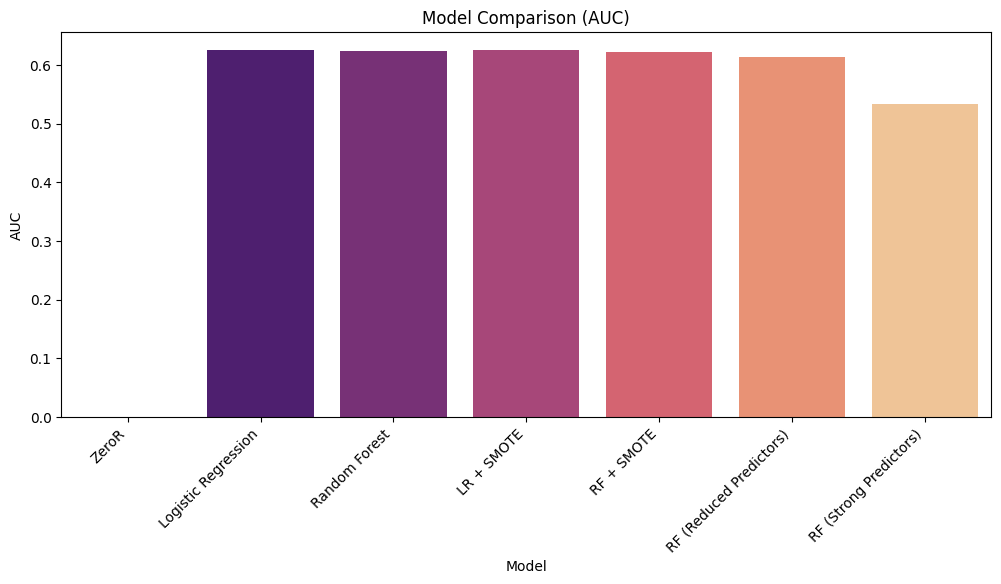

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(data=results_df, x="Model", y="AUC", palette="magma")
plt.title("Model Comparison (AUC)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("AUC")
plt.show()

# Conclusion

This project exlpored readmission prediction in the Diabetes 130-US Hospitals dataset. The models used, Logistic Regressiong and Random Forest, achieved an accuracy of around 61%, only slightly above the baseline. This reflects the inherent dificulty of predicting hospital readmission, which is influenced by many clinical and behavioral factors that were not reported in the dataset.

Feature importance analysis highlighted hospital-related variables (lab procedures, medications, number of diagnoses, and length of stay) as more predictive than demographics, with minimal indication of bias from race or sex. Grouping diagnosis codes into broader disease categories improved interpinterpretabilityrebaility without harming performance, but no feature group had very strong predictive power on its own.

Overall, the results suggest that although machine learning can capture some patterns related to readmission risk, the dataset lacks several key clinical and social determinants needed for high predictive accuracy.
